# Credit Risk — 03: IFRS 9 Expected Credit Loss Layer

**Series:** 01 EDA → 02 XGBoost model → 03 IFRS 9 ECL layer (this notebook).

Notebook 02 produced a discriminative model (test Gini ≈ 0.91). A bank does not
provision with a ranker — IFRS 9 requires **expected credit losses**:

$$\text{ECL} = \sum \; \text{PD} \times \text{LGD} \times \text{EAD} \times \text{DF}$$

with 12-month ECL for Stage 1 exposures and lifetime ECL for Stage 2/3. This notebook
builds that layer on top of the tuned model: **calibration** (a PD must be a
probability, not a score), **staging** via a significant-increase-in-credit-risk (SICR)
rule, explicit **LGD / EAD / maturity assumptions**, and **probability-weighted
scenarios** — with every assumption stated in a table and stress-tested at the end.

All parameters here are illustrative assumptions in the spirit of the standard, not a
bank's validated estimates; the point is the mechanics and their sensitivities.

## 1. Setup, data, and the tuned model from notebook 02

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "data/credit_risk_dataset.csv"
KAGGLE_DATASET = "laotse/credit-risk-dataset"
MIRROR_URL = (
    "https://gist.githubusercontent.com/eversonm/"
    "3d2b3cf0cd4b3c93f906377bba8f989c/raw/credit_risk_dataset.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print("Downloaded from mirror.")
    return path


df = pd.read_csv(fetch_data())
df = df.drop_duplicates()
df = df[(df.person_age <= 100) & (df.person_emp_length.fillna(0) <= 60)]

TARGET = "loan_status"
NUM_COLS = ["person_age", "person_income", "person_emp_length", "loan_amnt",
            "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
CAT_COLS = ["person_home_ownership", "loan_intent", "loan_grade",
            "cb_person_default_on_file"]
X, y = df[NUM_COLS + CAT_COLS], df[TARGET]

Found cached file: data/credit_risk_dataset.csv


In [2]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Winning configuration from notebook 02's two-stage search (random-stage winners with
# the grid-stage refinements applied). If you re-run the search in a different
# environment and it selects different values, paste your winner here.
XGB_PARAMS = dict(
    n_estimators=630, learning_rate=0.1349, max_depth=4, min_child_weight=2,
    subsample=0.9043, colsample_bytree=0.8365, gamma=0.01038, reg_lambda=5.8451,
    tree_method="hist", eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
)
SMOTE_PARAMS = dict(k_neighbors=5, sampling_strategy=0.8, random_state=RANDOM_STATE)

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM_COLS),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CAT_COLS),
])
model = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(**SMOTE_PARAMS)),
    ("clf", XGBClassifier(**XGB_PARAMS)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
book = X_test.copy()  # the held-out set plays the role of the current performing book
print(f"Train: {len(X_train)} | 'Reporting-date book': {len(book)} loans")

Train: 25927 | 'Reporting-date book': 6482 loans


## 2. From score to PD: calibration

The SMOTE-trained model's raw scores live in a rebalanced world; a PD that feeds
provisioning must be an honest probability. Isotonic calibration, cross-validated on
the training set only; the reliability diagram and mean-vs-realized check are the audit.

Raw (SMOTE-trained)  | ROC-AUC 0.9508 | Brier 0.0512 | mean 0.2284
Calibrated PD        | ROC-AUC 0.9515 | Brier 0.0504 | mean 0.2217
Realized default rate (book): 0.2188


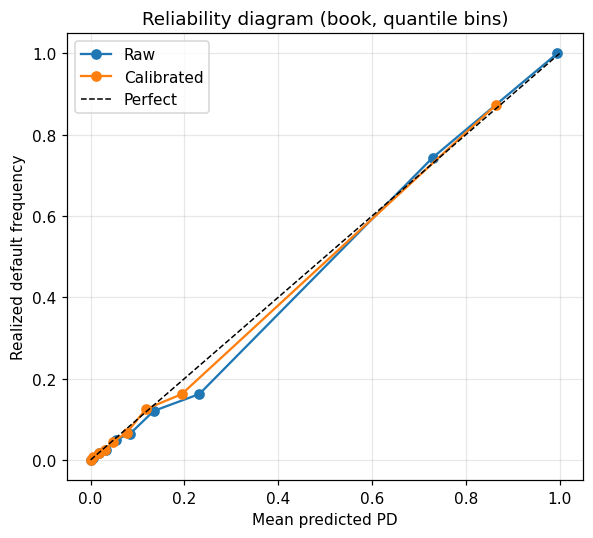

In [3]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

model.fit(X_train, y_train)
p_raw = model.predict_proba(X_test)[:, 1]

calibrated = CalibratedClassifierCV(model, method="isotonic", cv=5)
calibrated.fit(X_train, y_train)
pd12 = calibrated.predict_proba(X_test)[:, 1]  # 12-month PD proxy

for label, p in [("Raw (SMOTE-trained)", p_raw), ("Calibrated PD", pd12)]:
    print(f"{label:20s} | ROC-AUC {roc_auc_score(y_test, p):.4f} | "
          f"Brier {brier_score_loss(y_test, p):.4f} | mean {p.mean():.4f}")
print(f"Realized default rate (book): {y_test.mean():.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
for label, p in [("Raw", p_raw), ("Calibrated", pd12)]:
    frac, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac, marker="o", label=label)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
ax.set_xlabel("Mean predicted PD")
ax.set_ylabel("Realized default frequency")
ax.set_title("Reliability diagram (book, quantile bins)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. The assumption set

Every ECL number below is conditional on this table — in a bank each row is a governed,
validated estimate; here each is an explicit, changeable assumption:

| Component | Assumption | Rationale |
|---|---|---|
| **PD (12m)** | calibrated model output | point-in-time PD proxy; the dataset's label is default over the observed loan window, taken as ≈ 12-month horizon |
| **Origination PD** | average calibrated PD of the loan's `loan_grade` | grade is the underwriting decision — its average PD proxies risk at origination |
| **SICR → Stage 2** | PD ≥ 2 × origination PD **or** PD ≥ 20% (absolute backstop) | relative-deterioration rule with a backstop, mirroring common practice |
| **Stage 3** | PD ≥ 60% | unlikeliness-to-pay proxy on a performing book (no arrears data available) |
| **Lifetime PD** | $1-(1-\text{PD}_{12})^{M}$ | constant annual hazard over remaining maturity |
| **Maturity M** | by `loan_intent`: education/venture 4y, home improvement 5y, others 3y | typical consumer-loan tenors |
| **LGD** | by housing: OWN 55%, MORTGAGE 65%, RENT/OTHER 75% | unsecured consumer recoveries correlate with borrower stability/assets |
| **EAD** | `loan_amnt` | fully drawn term loans; no undrawn commitment, CCF not applicable |
| **Discounting** | at EIR ≈ `loan_int_rate` (median-imputed), mid-horizon | IFRS 9 requires discounting at the effective interest rate |
| **Scenarios** | base ×1.0 (w=50%), adverse PD ×1.4 & LGD +5pp (w=30%), favourable PD ×0.7 (w=20%) | forward-looking probability-weighted average |

In [4]:
MATURITY = {"EDUCATION": 4, "VENTURE": 4, "HOMEIMPROVEMENT": 5,
            "PERSONAL": 3, "MEDICAL": 3, "DEBTCONSOLIDATION": 3}
LGD_MAP = {"OWN": 0.55, "MORTGAGE": 0.65, "RENT": 0.75, "OTHER": 0.75}
SCENARIOS = {  # name: (weight, PD multiplier, LGD add-on)
    "base":       (0.50, 1.0, 0.00),
    "adverse":    (0.30, 1.4, 0.05),
    "favourable": (0.20, 0.7, 0.00),
}
STAGE2_REL, STAGE2_ABS, STAGE3_ABS = 2.0, 0.20, 0.60

ecl = book.copy()
ecl["pd12"] = pd12
ecl["orig_pd"] = ecl.groupby("loan_grade")["pd12"].transform("mean")
ecl["maturity"] = ecl["loan_intent"].map(MATURITY)
ecl["lgd"] = ecl["person_home_ownership"].map(LGD_MAP)
ecl["ead"] = ecl["loan_amnt"].astype(float)
ecl["eir"] = ecl["loan_int_rate"].fillna(ecl["loan_int_rate"].median()) / 100

ecl["stage"] = np.select(
    [ecl.pd12 >= STAGE3_ABS,
     (ecl.pd12 >= STAGE2_REL * ecl.orig_pd) | (ecl.pd12 >= STAGE2_ABS)],
    [3, 2], default=1,
)
print(ecl.groupby("stage").size().rename("loans").to_frame().T.to_string())

stage     1    2     3
loans  4951  478  1053


## 4. ECL computation

Stage 1 carries 12-month ECL discounted half a year at the EIR; Stage 2/3 carry
lifetime ECL with the constant-hazard lifetime PD discounted at half the remaining
maturity (mid-horizon approximation of the loss timing):

$$\text{ECL}_{12m} = \text{PD}_{12}\cdot\text{LGD}\cdot\text{EAD}\cdot(1+\text{EIR})^{-0.5},
\qquad
\text{ECL}_{life} = \left[1-(1-\text{PD}_{12})^{M}\right]\cdot\text{LGD}\cdot\text{EAD}\cdot(1+\text{EIR})^{-M/2}$$

In [5]:
def compute_ecl(frame: pd.DataFrame, pd_mult: float = 1.0, lgd_add: float = 0.0) -> pd.Series:
    """Per-loan ECL under a scenario, respecting stage allocation."""
    pd_s = (frame.pd12 * pd_mult).clip(upper=1.0)
    lgd_s = (frame.lgd + lgd_add).clip(upper=1.0)
    pd_life = 1 - (1 - pd_s) ** frame.maturity
    df12 = (1 + frame.eir) ** -0.5
    dflife = (1 + frame.eir) ** (-frame.maturity / 2)
    ecl12 = pd_s * lgd_s * frame.ead * df12
    ecllife = pd_life * lgd_s * frame.ead * dflife
    return np.where(frame.stage == 1, ecl12, ecllife)


ecl["ecl_base"] = compute_ecl(ecl)

stage_tbl = ecl.groupby("stage").agg(
    loans=("ead", "size"), ead=("ead", "sum"),
    mean_pd12=("pd12", "mean"), ecl=("ecl_base", "sum"),
)
stage_tbl["ead_share"] = stage_tbl.ead / stage_tbl.ead.sum()
stage_tbl["coverage"] = stage_tbl.ecl / stage_tbl.ead
print("Stage allocation and base-scenario ECL:")
print(stage_tbl.round(4).to_string())
print(f"\nPortfolio EAD: €{ecl.ead.sum():,.0f} | Base ECL: €{ecl.ecl_base.sum():,.0f} "
      f"| Coverage: {ecl.ecl_base.sum() / ecl.ead.sum():.2%}")

Stage allocation and base-scenario ECL:
       loans         ead  mean_pd12           ecl  ead_share  coverage
stage                                                                 
1       4951  45877025.0     0.0531  1.570752e+06     0.7346    0.0342
2        478   4393325.0     0.3039  1.710387e+06     0.0703    0.3893
3       1053  12182925.0     0.9770  7.152298e+06     0.1951    0.5871

Portfolio EAD: €62,453,275 | Base ECL: €10,433,437 | Coverage: 16.71%


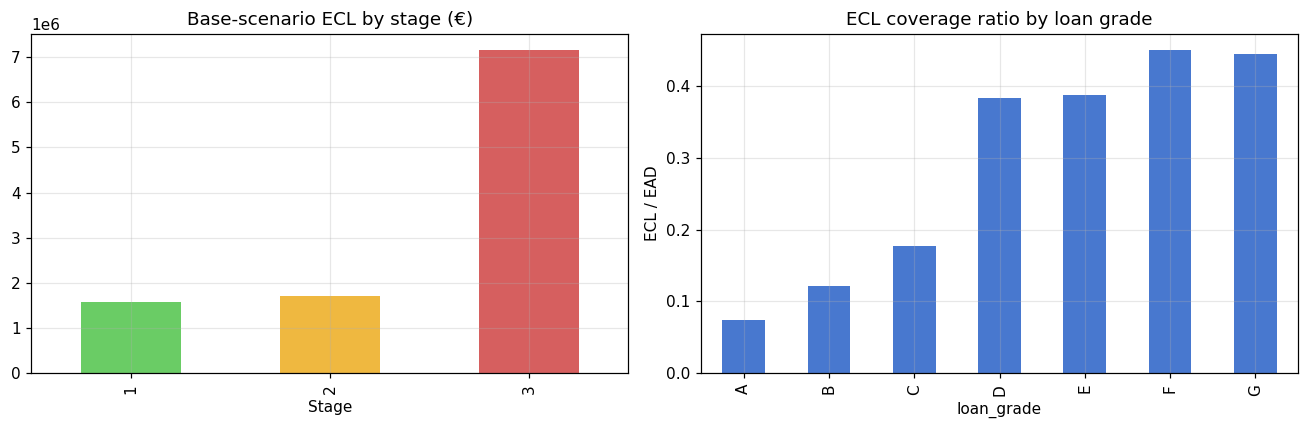

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stage_tbl["ecl"].plot.bar(ax=axes[0], color=["#6ACC65", "#EFB840", "#D65F5F"])
axes[0].set_title("Base-scenario ECL by stage (€)")
axes[0].set_xlabel("Stage")

cov_grade = ecl.groupby("loan_grade").apply(lambda g: g.ecl_base.sum() / g.ead.sum())
cov_grade.plot.bar(ax=axes[1], color="#4878CF")
axes[1].set_title("ECL coverage ratio by loan grade")
axes[1].set_ylabel("ECL / EAD")
plt.tight_layout()
plt.show()

The coverage curve is the sanity check that the whole chain works: provisioning rises
monotonically from A to G, and Stage 3 coverage approaches LGD (when PD → 1, ECL → 
LGD·EAD·DF) — both are structural properties an auditor would look for.

## 5. Forward-looking, probability-weighted ECL

In [7]:
rows = {}
for name, (w, pdm, lgda) in SCENARIOS.items():
    total = compute_ecl(ecl, pd_mult=pdm, lgd_add=lgda).sum()
    rows[name] = {"weight": w, "pd_mult": pdm, "lgd_add": lgda, "ECL": total}
scen = pd.DataFrame(rows).T
scen["weighted"] = scen.weight * scen.ECL
weighted_ecl = scen.weighted.sum()
fmt = scen.copy()
fmt["weight"] = (fmt.weight * 100).map("{:.0f}%".format)
fmt["lgd_add"] = (fmt.lgd_add * 100).map("{:+.0f}pp".format)
for c in ["ECL", "weighted"]:
    fmt[c] = fmt[c].map("€{:,.0f}".format)
print(fmt.to_string())
print(f"\nProbability-weighted ECL: €{weighted_ecl:,.0f} "
      f"(vs base €{scen.loc['base', 'ECL']:,.0f} — "
      f"{weighted_ecl / scen.loc['base', 'ECL'] - 1:+.1%})")

           weight  pd_mult lgd_add          ECL    weighted
base          50%      1.0    +0pp  €10,433,437  €5,216,718
adverse       30%      1.4    +5pp  €12,159,373  €3,647,812
favourable    20%      0.7    +0pp   €9,459,457  €1,891,891

Probability-weighted ECL: €10,756,421 (vs base €10,433,437 — +3.1%)


The weighted number exceeds the base ECL: because losses are convex in PD and the
adverse scenario is weighted more heavily than its mirror image, the probability-
weighted average is **not** the ECL of the average scenario — the asymmetry is the
entire reason IFRS 9 mandates multiple scenarios instead of one central forecast.

## 6. Sensitivity of the provision to the assumptions

Base ECL: €10,433,437

                                  ECL        delta delta_pct
LGD +10pp (all)           €11,887,050  €+1,453,614    +13.9%
LGD -10pp (all)            €8,979,823  €-1,453,614    -13.9%
PD ×1.2 (all)             €10,919,076    €+485,640     +4.7%
PD ×0.8 (all)              €9,853,097    €-580,339     -5.6%
Adverse weight 30%→50%    €11,101,609    €+668,172     +6.4%
Stage-2 backstop 20%→15%  €10,993,833    €+560,396     +5.4%


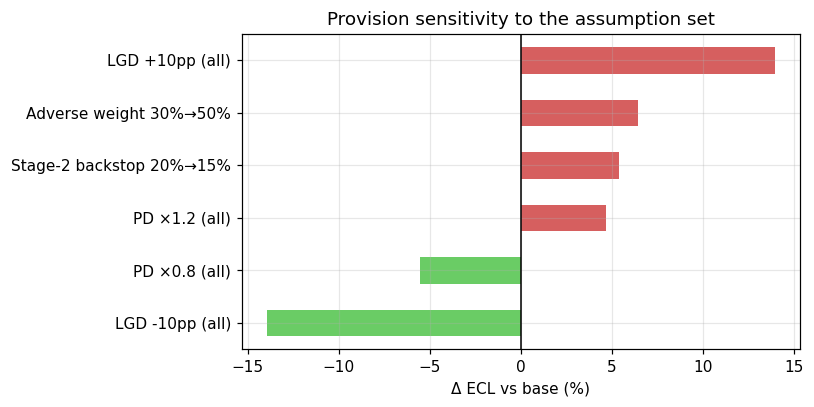

In [8]:
base_total = ecl.ecl_base.sum()
sens = {
    "LGD +10pp (all)": compute_ecl(ecl, lgd_add=0.10).sum(),
    "LGD -10pp (all)": compute_ecl(ecl, lgd_add=-0.10).sum(),
    "PD ×1.2 (all)": compute_ecl(ecl, pd_mult=1.2).sum(),
    "PD ×0.8 (all)": compute_ecl(ecl, pd_mult=0.8).sum(),
    "Adverse weight 30%→50%": (0.30 * scen.loc["base", "ECL"]
                               + 0.50 * scen.loc["adverse", "ECL"]
                               + 0.20 * scen.loc["favourable", "ECL"]),
    "Stage-2 backstop 20%→15%": None,  # filled below
}
ecl_tight = ecl.copy()
ecl_tight["stage"] = np.select(
    [ecl_tight.pd12 >= STAGE3_ABS,
     (ecl_tight.pd12 >= STAGE2_REL * ecl_tight.orig_pd) | (ecl_tight.pd12 >= 0.15)],
    [3, 2], default=1,
)
sens["Stage-2 backstop 20%→15%"] = compute_ecl(ecl_tight).sum()

sens_df = pd.DataFrame({"ECL": sens}).assign(
    delta=lambda d: d.ECL - base_total,
    delta_pct=lambda d: d.ECL / base_total - 1,
)
print(f"Base ECL: €{base_total:,.0f}\n")
fmt = sens_df.copy()
fmt["ECL"] = fmt.ECL.map("€{:,.0f}".format)
fmt["delta"] = fmt.delta.map("€{:+,.0f}".format)
fmt["delta_pct"] = (fmt.delta_pct * 100).map("{:+.1f}%".format)
print(fmt.to_string())

fig, ax = plt.subplots(figsize=(7.5, 3.8))
(sens_df["delta_pct"].sort_values() * 100).plot.barh(
    ax=ax, color=["#6ACC65" if v < 0 else "#D65F5F" for v in sens_df["delta_pct"].sort_values()])
ax.axvline(0, c="k", lw=1)
ax.set_xlabel("Δ ECL vs base (%)")
ax.set_title("Provision sensitivity to the assumption set")
plt.tight_layout()
plt.show()

## 7. What this layer is and is not — stated plainly

1. **The PD is point-in-time, not through-the-cycle.** A calibrated model score
   reflects current conditions; a production IFRS 9 framework links PD to macro
   forecasts per scenario rather than applying flat multipliers.
2. **The label is a single observed default outcome**, not a seasoned 12-month default
   flag with arrears data — so staging uses PD proxies (doubling rule, backstops)
   instead of days-past-due triggers, and Stage 3 is an unlikeliness-to-pay proxy.
3. **No term structure.** Lifetime PD uses a constant hazard; real models build
   PD term structures from vintage data, with prepayment and amortization profiles
   feeding time-varying EAD.
4. **LGD/EAD are assumption tables**, not workout-data estimates; the sensitivity
   section exists precisely because these are the provision's biggest levers —
   a ±10pp LGD move shifts the provision by roughly ±14%.

The mechanics, however, are the real ones: calibrated PD × LGD × EAD × discounting,
staged allocation with SICR logic, probability-weighted scenarios, and sensitivity
disclosure — the full chain from a Kaggle CSV to a provision number a finance function
could interrogate line by line.